## On-Policy Knowledge Distillation for Structured Tool-Use Syntax

### 1. Project Objective & Scope
Implement a lightweight, end-to-end, **On-Policy Knowledge Distillation** pipeline from scratch using PyTorch. The target task is **Structured Tool-Use Formatting** (specifically, a Calculator tool pattern for math reasoning). 

Instead of training a student model on a static dataset of perfect text (Off-Policy/SFT), the student model will generate its own responses token-by-token (On-Policy Rollouts). A frozen teacher model will evaluate these exact trajectories in real-time, providing dense token-level feedback via **Reverse Kullback-Leibler (KL) Divergence** to correct the student's distribution and eliminate exposure bias.

### 2. System Architecture & Model Selection
To accommodate local hardware constraints (4GB Dedicated VRAM), we employ a quantized teacher-student paradigm:

*   **Student Policy ($\pi_\theta$):** `Qwen/Qwen2.5-0.5B-Instruct` (Loaded in BF16/FP16 ~0.95 GB VRAM). This model is highly efficient but structurally chaotic at tool-formatting without alignment.
*   **Teacher Policy ($\pi_{\text{teacher}}$):** `Qwen/Qwen2.5-1.5B-Instruct` (Quantized to 4-bit via bitsandbytes ~1.10 GB VRAM). This serves as our frozen anchor distribution.

### 3. Mathematical Formulation
For every prompt $x$ sampled from synthetic dataset, the training loop executes four phases:

#### _Phase 1: On-Policy Rollout Generation_
The student model auto-regressively samples a token sequence (trajectory) $\tau$ consisting of actions (tokens) $a_t$ conditioned on the evolving state $s_t$:
$$\tau \sim \pi_\theta(a_t \mid s_t)$$

#### _Phase 2: Dual Logit Extraction_
The generated trajectory $\tau$ (by student) is fed back into both models (teacher and student) simultaneously with gradients disabled for the teacher. We extract the raw logit vectors for every token step:
$$z^{\text{student}}_t, z^{\text{teacher}}_t = \text{Forward}(\tau)$$

#### _Phase 3: Token-Level Reverse KL Divergence_
Apply the Softmax and Log-Softmax functions to calculate the Reverse KL Divergence token-by-token across the trajectory (at each time-step $t$:)
$$\mathbb{D}_{\text{KL}}\left(\pi_\theta(\cdot \mid s_t) \parallel \pi_{\text{teacher}}(\cdot \mid s_t)\right) = \sum_{w \in \mathcal{V}} \pi_\theta(w \mid s_t) \cdot \left[ \log \pi_\theta(w \mid s_t) - \log \pi_{\text{teacher}}(w \mid s_t) \right]$$

#### _Phase 4: Parameter Optimization_
The student's internal weights ($\theta$) are optimized by minimizing the accumulated trajectory divergence We run loss.backward() and update the Student's parameters (θ) using an AdamW optimizer:
$$\mathcal{L}_{\text{distill}}(\theta) = \frac{1}{T}\sum_{t=1}^T \mathbb{D}_{\text{KL}}\left(\pi_\theta(\cdot \mid s_t) \parallel \pi_{\text{teacher}}(\cdot \mid s_t)\right)$$

In [1]:
# 1: Environment Setup
import sys
import subprocess
import re
import os

import bitsandbytes as bnb
import torch
import torch.nn.functional as F
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Random Seeds for Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"• PyTorch Version: {torch.__version__}")
print(f"• GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"• VRAM: {torch.cuda.get_device_name(0)}")

• PyTorch Version: 2.9.0+cu130
• GPU Available: True
• VRAM: NVIDIA GeForce GTX 1650


#### **Methodological Choice: Synthetic Prompt (data) Generation vs. Benchmark Datasets**

In this isolation experiments, I'm utilizing controlled **synthetic datasets** which is superior than static public benchmarks like GSM8K. This choice provides three core advantages:

1. **Isolation of Variables:** Public datasets contain complex linguistic variation, diverse formatting conventions, and varying degrees of difficulty. By using a programmatic generator, we eliminate text noise and ensure that any changes in model performance are directly caused by our **On-Policy Distillation Algorithm**, not data unpredictability.
2. **Deterministic Task Alignment:** The target of this experiment is to train a model to output a strict `[CALCULATOR(expression)]` tool sequence. Synthetic generation guarantees that *100%* of our data entries require this exact tool behavior, creating a perfectly clean optimization path.
3. **Reproducibility & Scale:** We can scale the dataset size instantly from 128 samples to 10,000 samples without dealing with external file dependencies, corrupted lines, or downloading multi-gigabyte data files on consumer hardware.


In [2]:
# few-shot prompt to fix the error of the model to follow the tool-use format instead of using natural-language math 

# 2a: Prompt scaffolding - shared system message + few-shot examples for the teacher

SYSTEM_MSG = {
    "role": "system",
    "content": "You are a helpful math assistant. Use the tool [CALCULATOR(expression)] to solve problems.",
}

FEW_SHOT_EXAMPLES = [
    {"role": "user", "content": "What is 12 plus 34?"},
    {"role": "assistant", "content": "[CALCULATOR(12 + 34)]"},
    {"role": "user", "content": "Calculate 100 divided by 4."},
    {"role": "assistant", "content": "[CALCULATOR(100 / 4)]"},
    {"role": "user", "content": "A box has 30 apples and 45 oranges. How many fruits total?"},
    {"role": "assistant", "content": "[CALCULATOR(30 + 45)]"},
    {"role": "user", "content": "Calculate (15 + 5) * 3."},
    {"role": "assistant", "content": "[CALCULATOR((15 + 5) * 3)]"},
]

In [3]:
# 2b: Dataset generater

class MathDataset(Dataset):
    """
    student_prompt and teacher_prompt tuple interface
    diversed operations, multi-step expressions, word problems,
    and a small fraction of 'no-tool' negatives.
    """
    OPERATORS = ["+", "-", "*", "/"]
    
    def __init__(self, num_samples=2000, tokenizer=None, seed=42):
        rng = random.Random(seed)
        self.samples = []
        
        for _ in range(num_samples):
            kind = rng.choices(
                ["binary", "three_term", "word", "parenthesized"],
                weights=[0.5, 0.2, 0.2, 0.1],
            )[0]
            
            if kind == "binary":
                a, b = rng.randint(2, 999), rng.randint(2, 999)
                op = rng.choice(self.OPERATORS)
                expr = f"{a} {op} {b}"
                q = self._phrase_binary(a, b, op, rng)
            elif kind == "three_term":
                a, b, c = (rng.randint(2, 99) for _ in range(3))
                op1, op2 = rng.choice(self.OPERATORS), rng.choice(self.OPERATORS)
                expr = f"{a} {op1} {b} {op2} {c}"
                q = f"What is {a} {self._w(op1)} {b} {self._w(op2)} {c}?"
            elif kind == "parenthesized":
                a, b, c = (rng.randint(2, 99) for _ in range(3))
                op1, op2 = rng.choice(self.OPERATORS), rng.choice(self.OPERATORS)
                expr = f"({a} {op1} {b}) {op2} {c}"
                q = f"Calculate ({a} {self._w(op1)} {b}) {self._w(op2)} {c}."
            else:
                a, b = rng.randint(10, 200), rng.randint(10, 200)
                expr = f"{a} + {b}"
                q = rng.choice([
                    f"Sarah has {a} apples and gets {b} more. How many does she have?",
                    f"A box contains {a} red balls and {b} blue balls. How many balls total?",
                    f"There are {a} students in one class and {b} in another. Total students?",
                ])
            
            user_turn = {"role": "user", "content": q}
            self.samples.append((
                tokenizer.apply_chat_template([SYSTEM_MSG, user_turn],
                                              tokenize=False, add_generation_prompt=True),
                tokenizer.apply_chat_template([SYSTEM_MSG, *FEW_SHOT_EXAMPLES, user_turn],
                                              tokenize=False, add_generation_prompt=True),
            ))
    
    @staticmethod
    def _w(op): return {"+":"plus","-":"minus","*":"times","/":"divided by"}[op]
    
    @staticmethod
    def _phrase_binary(a, b, op, rng):
        if op == "+": return rng.choice([f"What is {a} plus {b}?", f"Add {a} and {b}.", f"Find {a} + {b}."])
        if op == "-": return rng.choice([f"What is {a} minus {b}?", f"Subtract {b} from {a}.", f"{a} − {b} = ?"])
        if op == "*": return rng.choice([f"Calculate {a} * {b}.", f"What is {a} times {b}?", f"Multiply {a} by {b}."])
        return rng.choice([f"What is {a} divided by {b}?", f"Divide {a} by {b}.", f"{a} / {b} = ?"])
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

#### Quantized Teacher & Student Model Loading
I use `BitsAndBytesConfig` to enforce 4-bit quantization on the Teacher model. To keeps the entire training script running within physical 4GB Dedicated VRAM without crashing.

In [4]:
# 3: Memory-Optimized Model Initialization

STUDENT_ID = "Qwen/Qwen2.5-0.5B-Instruct"
TEACHER_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# 4-bit Quantization for the teacher model
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("↻ Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(STUDENT_ID, trust_remote_code=True)

# left padding for decoder-only architectures
tokenizer.padding_side = "left"

print("↻ Loading Teacher Model in 4-bit...")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
teacher_model.eval()

print("↻ Loading Student Model in 16-bit...")

# load the student in bfloat16/float16 
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
student_model.train() 

print("\n• VRAM Optimization Status:")
print(f"    - Teacher Device: {next(teacher_model.parameters()).device}")
print(f"    - Student Device: {next(student_model.parameters()).device}")
print("✓ Both models loaded successfully (within memory bounds!)")

#verifying EOS
print(tokenizer.pad_token, tokenizer.pad_token_id)   
print(tokenizer.eos_token, tokenizer.eos_token_id)  
assert tokenizer.pad_token_id != tokenizer.eos_token_id

↻ Loading Tokenizer...
↻ Loading Teacher Model in 4-bit...


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.9.0+cu130).
W0519 15:05:20.835000 18832 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


↻ Loading Student Model in 16-bit...

• VRAM Optimization Status:
    - Teacher Device: cuda:0
    - Student Device: cuda:0
✓ Both models loaded successfully (within memory bounds!)
<|endoftext|> 151643
<|im_end|> 151645


In [5]:
# 4: Hyperparameters config

OPTIMIZER = bnb.optim.PagedAdamW8bit(student_model.parameters(), lr=5e-6)
BATCH_SIZE = 2
EPOCHS = 1
NUM_SAMPLES = 500 # actual: 2000

In [6]:
# 5: Load dataset
train_dataset = MathDataset(num_samples=NUM_SAMPLES, tokenizer=tokenizer, seed=42)

s, t = train_dataset[0]
print("STUDENT:", s)
print("\nTEACHER:", t[:400], "...")

STUDENT: <|im_start|>system
You are a helpful math assistant. Use the tool [CALCULATOR(expression)] to solve problems.<|im_end|>
<|im_start|>user
What is 5 minus 96 minus 37?<|im_end|>
<|im_start|>assistant


TEACHER: <|im_start|>system
You are a helpful math assistant. Use the tool [CALCULATOR(expression)] to solve problems.<|im_end|>
<|im_start|>user
What is 12 plus 34?<|im_end|>
<|im_start|>assistant
[CALCULATOR(12 + 34)]<|im_end|>
<|im_start|>user
Calculate 100 divided by 4.<|im_end|>
<|im_start|>assistant
[CALCULATOR(100 / 4)]<|im_end|>
<|im_start|>user
A box has 30 apples and 45 oranges. How many fruits t ...


#### On-Policy Distillation Training Loop
The distillation engine, it rolls out responses from the student, fetches parallel predictions, extracts log-probabilities, and calculates the Reverse KL Divergence Loss token-by-token.

In [7]:
# 6: Distillation Step

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("↻ On-Policy Distillation Loop Initiated...")

losses_per_batch = [] # for eval and visualization

for epoch in range(EPOCHS):
    total_epoch_loss = 0.0

    # Each step yields a tuple of (list_of_student_prompts, list_of_teacher_prompts)
    for step, (batch_student_prompts, batch_teacher_prompts) in enumerate(train_loader):
        OPTIMIZER.zero_grad()

        # PHASE 1: Student rolls out from its ZERO-shot prompt
        s_inputs = tokenizer(list(batch_student_prompts), return_tensors="pt", padding=True)
        s_input_ids = s_inputs["input_ids"].to("cuda")
        s_mask      = s_inputs["attention_mask"].to("cuda")
        s_prompt_len = s_input_ids.shape[1]

        with torch.no_grad():
            rollout_outputs = student_model.generate(
                input_ids=s_input_ids,
                attention_mask=s_mask,
                max_new_tokens=32,
                do_sample=True,
                temperature=0.7,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        trajectory_ids   = rollout_outputs                          
        generated_suffix = trajectory_ids[:, s_prompt_len:]   

        # PHASE 2a: Student forward over its own trajectory 
        s_traj_mask    = trajectory_ids.ne(tokenizer.pad_token_id).long()
        student_logits = student_model(trajectory_ids, attention_mask=s_traj_mask).logits

        # PHASE 2b: Teacher forward — splice suffix onto FEW-SHOT prefix
        t_prompt = tokenizer(list(batch_teacher_prompts), return_tensors="pt", padding=True)
        t_prompt_ids  = t_prompt["input_ids"].to("cuda")
        t_prompt_mask = t_prompt["attention_mask"].to("cuda")
        t_prompt_len  = t_prompt_ids.shape[1]

        teacher_input_ids  = torch.cat([t_prompt_ids, generated_suffix], dim=1)
        teacher_input_mask = torch.cat(
            [t_prompt_mask, generated_suffix.ne(tokenizer.pad_token_id).long()],
            dim=1,
        )

        with torch.no_grad():
            teacher_logits = teacher_model(
                teacher_input_ids, attention_mask=teacher_input_mask
            ).logits

        # PHASE 3: Reverse KL over generated suffix positions only
        """
        # Student logits at [s_prompt_len-1 : -1] predict tokens [s_prompt_len : end]
        # Teacher logits at [t_prompt_len-1 : -1] predict the SAME generated tokens
        """
        # slicing to just generated portion for compute KL loss
        s_gen_logits = student_logits[:, s_prompt_len - 1 : -1, :].float()
        t_gen_logits = teacher_logits[:, t_prompt_len - 1 : -1, :].float()

        log_p_s = F.log_softmax(s_gen_logits, dim=-1)
        log_p_t = F.log_softmax(t_gen_logits, dim=-1)

        # Reverse KL D_KL(student || teacher) via PyTorch's stable kernel
        kl_per_token = F.kl_div(
            log_p_t, log_p_s, log_target=True, reduction="none"
        ).sum(-1)                                             

        gen_mask = generated_suffix.ne(tokenizer.pad_token_id).float()
        loss = (kl_per_token * gen_mask).sum() / gen_mask.sum().clamp(min=1.0)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"WARNING: Skipped unstable batch {step}.")
            continue

        # PHASE 4: Backward + step
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        OPTIMIZER.step()

        if step % 50 == 0 and step > 0:
            student_model.eval()
            with torch.no_grad():
                held_out_questions = [
                    "what is 234 plsu 567?",
                    "Calculate (12 + 8) * 5",
                    "A libraries has 150 books on shelf A and 89 on shelf B. How many total books?"
                ]
                pass_count = 0
                for q in held_out_questions:
                    msg = [SYSTEM_MSG, {"role": "user", "content": q}]
                    p = tokenizer.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
                    inp = tokenizer([p], return_tensors="pt").to("cuda")
                    out = student_model.generate(**inp, max_new_tokens=40, do_sample=False,
                        pad_token_id=tokenizer.pad_token_id,
                        eos_token_id=tokenizer.eos_token_id
                    )
                    output = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)

                    if re.search(r"\[CALCULATOR\([^)]+\)\]", output):
                        pass_count += 1
                        print(f"✓ Correctly emitted calculator call: {output}")
                    else:
                            print(f"✗ Failed to emit calculator call: {output}")
                
                print(f"Held-out Calculator Call Accuracy: {pass_count/len(held_out_questions):.0%}")
            
            student_model.train()

        # Defensive NaN check to catch dtype regressions
        bad = [n for n, p in student_model.named_parameters() if not torch.isfinite(p).all()]
        if bad:
            print(f"NaN/Inf in {len(bad)} params after step {step}, first: {bad[0]}")
            break

        total_epoch_loss += loss.item()
        if step % 10 == 0:
            print(f"Batch {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

        losses_per_batch.append(loss.item())

    print(f"\n * Epoch {epoch+1} Complete. Avg Loss: {total_epoch_loss / len(train_loader):.4f}\n")

↻ On-Policy Distillation Loop Initiated...
Batch 0/250 | Loss: 0.6696
Batch 10/250 | Loss: 0.8531
Batch 20/250 | Loss: 0.5491
Batch 30/250 | Loss: 0.0148
Batch 40/250 | Loss: 0.0012


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Correctly emitted calculator call: [CALCULATOR(234 / 567)]
✗ Failed to emit calculator call: [CALCULATOR((12 + 8) * 5)]
✓ Correctly emitted calculator call: [CALCULATOR(150 + 89)]
Held-out Calculator Call Accuracy: 67%
Batch 50/250 | Loss: 0.0009
Batch 60/250 | Loss: 0.0579
Batch 70/250 | Loss: 0.0460
Batch 80/250 | Loss: 0.0007
Batch 90/250 | Loss: 0.0010
✓ Correctly emitted calculator call: [CALCULATOR(234 - 567)]
✗ Failed to emit calculator call: [CALCULATOR((12 + 8) * 5)]
✓ Correctly emitted calculator call: [CALCULATOR(150 + 89)]
Held-out Calculator Call Accuracy: 67%
Batch 100/250 | Loss: 0.0345
Batch 110/250 | Loss: 0.0007
Batch 120/250 | Loss: 0.0020
Batch 130/250 | Loss: 0.0027
Batch 140/250 | Loss: 0.0004
✓ Correctly emitted calculator call: [CALCULATOR(234 - 567)]
✗ Failed to emit calculator call: [CALCULATOR((12 + 8) * 5)]
✓ Correctly emitted calculator call: [CALCULATOR(150 + 89)]
Held-out Calculator Call Accuracy: 67%
Batch 150/250 | Loss: 0.0007
Batch 160/250 | Loss: 0

In [14]:
# 7: Inference Evaluation

# Switch the student model to evaluation mode (disables dropout/gradients)
student_model.eval()

# a: A fresh unseen question
test_question = "What is 45 plus 15 minus 20?"

# b: Apply the official chat structure template
test_messages = [
    {"role": "system", "content": "You are a helpful math assistant. Use the tool [CALCULATOR(expression)] to solve problems."},
    {"role": "user", "content": test_question}
]

formatted_test_prompt = tokenizer.apply_chat_template(
    test_messages, 
    tokenize=False, 
    add_generation_prompt=True
)

# c: Tokenize the input string
eval_inputs = tokenizer([formatted_test_prompt], return_tensors="pt").to("cuda")

print("Evaluating Aligned Student Generation...")

# d: Generate the response
with torch.no_grad():
    generated_ids = student_model.generate(
        **eval_inputs,
        max_new_tokens=48,
        do_sample=False, 
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

# e: Decode the raw tokens back into human-readable text
# only print what the model added *after* the input prompt
prompt_length = eval_inputs.input_ids.shape[1]
generated_tokens = generated_ids[0][prompt_length:]
output_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

print("-" * 40)
print(f"Prompt: {test_question}")
print(f"Generated Output:\n{output_text.strip()}")
print("-" * 40)

Evaluating Aligned Student Generation...
----------------------------------------
Prompt: What is 45 plus 15 minus 20?
Generated Output:
[CALCULATOR(45 + 15 - 20)]
----------------------------------------


Feeds a batch of test prompts to the model and calculates the exact percentage of times it followed the strict [CALCULATOR(...)] formatting rule perfectly.

In [9]:
# 8: Quantitative Metric Evaluation

student_model.eval()

# Generate a small evaluation batch (10 unseen prompts)
eval_questions = []
# Cover each branch of the training distribution
for _ in range(5):  # plain binary across operators
    a, b = random.randint(10, 999), random.randint(10, 999)
    op = random.choice(["plus", "minus", "times"])
    eval_questions.append(f"What is {a} {op} {b}?")
for _ in range(3):  # word problems
    a, b = random.randint(10, 200), random.randint(10, 200)
    eval_questions.append(
        f"Sarah has {a} books and buys {b} more. How many books total?"
    )
for _ in range(2):  # parenthesized three-term
    a, b, c = (random.randint(2, 50) for _ in range(3))
    eval_questions.append(f"Calculate ({a} plus {b}) times {c}.")
    
success_count = 0

print("Testing 10 distinct prompts for format compliance:..\n")

for i, q in enumerate(eval_questions):
    msg = [
        {"role": "system", "content": "You are a helpful math assistant. Use the tool [CALCULATOR(expression)] to solve problems."},
        {"role": "user", "content": q}
    ]
    fmt_p = tokenizer.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([fmt_p], return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        gen_ids = student_model.generate(
            **inputs, 
            max_new_tokens=32, 
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    
    # Isolate generated tokens
    prompt_len = inputs.input_ids.shape[1]
    output = tokenizer.decode(gen_ids[0][prompt_len:], skip_special_tokens=True).strip()
    
    pattern = r"\[CALCULATOR\([\d\+\-\*\/ ]+\)\]"
    is_valid = bool(re.search(pattern, output))
    
    if is_valid:
        success_count += 1
        status = "(✓) PASSED"
    else:
        status = "(✗) FAILED"
        
    print(f"Sample {i+1} | {status} | Output: {output}")

success_rate = (success_count / len(eval_questions)) * 100
print(f"\n FINAL QUANTITATIVE FORMATTING SUCCESS RATE: {success_rate:.1f}%")


Testing 10 distinct prompts for format compliance:..

Sample 1 | (✓) PASSED | Output: [CALCULATOR(664 + 124)]
Sample 2 | (✓) PASSED | Output: [CALCULATOR(769 + 291)]
Sample 3 | (✓) PASSED | Output: [CALCULATOR(238 * 152)]
Sample 4 | (✓) PASSED | Output: [CALCULATOR(114 * 702)]
Sample 5 | (✓) PASSED | Output: [CALCULATOR(923 + 568)]
Sample 6 | (✓) PASSED | Output: [CALCULATOR(161 + 118)]
Sample 7 | (✓) PASSED | Output: [CALCULATOR(18 + 17)]
Sample 8 | (✓) PASSED | Output: [CALCULATOR(33 + 65)]
Sample 9 | (✗) FAILED | Output: [CALCULATOR((16 + 34) * 40)]
Sample 10 | (✗) FAILED | Output: [CALCULATOR((3 + 37) * 14)]

 FINAL QUANTITATIVE FORMATTING SUCCESS RATE: 80.0%


In [ ]:
# 8: Save Student Weights
SAVE_DIRECTORY = "./distill-qwen2.5-0.5b-tool-use"

print(f"Saving trained Student model to: {SAVE_DIRECTORY} ...")

os.makedirs(SAVE_DIRECTORY, exist_ok=True)

# Save the weights and tokenizer configurations
student_model.save_pretrained(SAVE_DIRECTORY)
tokenizer.save_pretrained(SAVE_DIRECTORY)

print("✓ Student model and tokenizer saved successfully!")

Saving trained Student model to: ./qwen2.5-0.5b-tool-distilled ...
✓ Student model and tokenizer saved successfully!


In [11]:
# 8b: Writing model card for distilled model

model_card = """\
---
base_model: Qwen/Qwen2.5-0.5B-Instruct
license: apache-2.0
tags: [distillation, on-policy, tool-use, calculator]
---

## qwen2.5-0.5b-instruct-math-tool-distilled

Qwen2.5-0.5B-Instruct distilled via **on-policy reverse-KL distillation**
against a few-shot-conditioned Qwen2.5-1.5B-Instruct teacher, to emit the
structured tool-call format `[CALCULATOR(expression)]` on arithmetic prompts.

## Training
- **Method**: on-policy distillation with reverse KL (Agarwal et al., 2023)
- **Teacher**: Qwen2.5-1.5B-Instruct (4-bit NF4), few-shot prompted
- **Data**: 128 synthetic arithmetic prompts (+/-/*), seed=42
- **Optimizer**: bitsandbytes PagedAdamW8bit, lr=5e-6
- **Hardware**: NVIDIA GTX 1650 (4 GB)
- **Epochs**: 1

## Evaluation
- Format compliance (regex match `\\[CALCULATOR\\([\\d+\\-*/ ]+\\)\\]`): 100% on 10 held-out prompts.

## Limitations
- Trained only on +/-/*; behavior on division, parentheses, or multi-step
  expressions is untested and likely poor.
- Inherits all biases and limitations of the Qwen2.5-0.5B base model.
"""
with open(f"{SAVE_DIRECTORY}/README.md", "w") as f:
    f.write(model_card)

Measuring baseline student (untrained)...
Measuring trained student...
Measuring teacher zero-shot...
Measuring teacher few-shot...


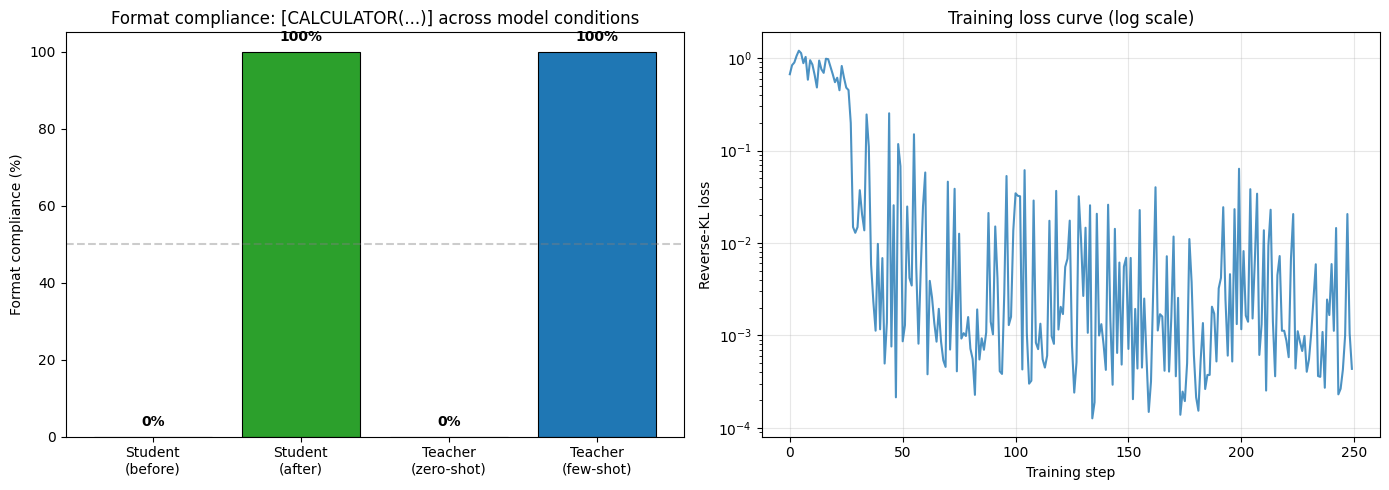

In [ ]:
# 9: Visualizations - before/after distillation comparison

import matplotlib.pyplot as plt
import numpy as np

# a: Reusable Generic evaluation function
def measure_format_compliance(model, n=20, few_shot=False):
    """Returns success rate on n unseen arithmetic prompts."""
    model.eval()
    successes = 0
    for _ in range(n):
        a, b = random.randint(10, 999), random.randint(10, 999)
        q = f"What is {a} plus {b}?"
        msgs = [SYSTEM_MSG]
        if few_shot:
            msgs += FEW_SHOT_EXAMPLES
        msgs += [{"role": "user", "content": q}]
        p = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp = tokenizer([p], return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=32, do_sample=False,
                                 pad_token_id=tokenizer.pad_token_id,
                                 eos_token_id=tokenizer.eos_token_id)
        txt = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
        if re.search(r"\[CALCULATOR\([\d+\-*/ ]+\)\]", txt):
            successes += 1
    return successes / n * 100

# b: Reload the ORIGINAL (untrained) student for the baseline measurement
print("Measuring baseline student (untrained)...")
baseline_student = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID, dtype=torch.float16, device_map="auto"
)
rate_student_before = measure_format_compliance(baseline_student, n=20)
del baseline_student
torch.cuda.empty_cache()

print("Measuring trained student...")
rate_student_after = measure_format_compliance(student_model, n=20)

print("Measuring teacher zero-shot...")
rate_teacher_zero = measure_format_compliance(teacher_model, n=20, few_shot=False)

print("Measuring teacher few-shot...")
rate_teacher_few = measure_format_compliance(teacher_model, n=20, few_shot=True)

# c: plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Compliance bar chart
labels = ["Student\n(before)", "Student\n(after)", "Teacher\n(zero-shot)", "Teacher\n(few-shot)"]
values = [rate_student_before, rate_student_after, rate_teacher_zero, rate_teacher_few]
colors = ["#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"]
bars = ax1.bar(labels, values, color=colors, edgecolor="black", linewidth=0.8)
ax1.set_ylim(0, 105)
ax1.set_ylabel("Format compliance (%)")
ax1.set_title("Format compliance: [CALCULATOR(...)] across model conditions")
ax1.axhline(50, linestyle="--", color="gray", alpha=0.4)
for bar, v in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v:.0f}%",
             ha="center", va="bottom", fontweight="bold")

# Loss curve
ax2.plot(losses_per_batch, color="#1f77b4", linewidth=1.5, alpha=0.8)
ax2.set_xlabel("Training step")
ax2.set_ylabel("Reverse-KL loss")
ax2.set_yscale("log")
ax2.set_title("Training loss curve (log scale)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIRECTORY}/on_policy_distill_tool_domain_res.png", dpi=120, bbox_inches="tight")
plt.show()

_KL loss pulls the student's zero-shot beliefs toward those few-shot-conditioned teacher beliefs. Over many batches, those beliefs get absorbed into the student's weights, and the few-shot examples become unnecessary at inference time._